In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report

In [2]:
df = pd.read_csv("Telco_Cusomer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# dropping the customer id
df.drop(columns=['customerID'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [5]:
# looking for duplicates
mask = df.duplicated()
print(f"duplicates: {len(df[mask == True])}")

duplicates: 22


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
# looking for null values
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# converting total charge feature from object type to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Exploratory Data Analysis (EDA)

In [9]:
# hist plots for continuous features
def histogram(data, column, bins, color):
    plt.figure(figsize=(8,5))
    hist = sns.histplot(data,
                 x= column,
                 kde=True,
                 bins=bins,
                 color=color
                )
    col_mean = data[column].mean()
    col_median = data[column].median()
    plt.axvline(x=col_mean, linestyle="--", color='green', label='Mean')
    plt.axvline(x=col_median, linestyle="--", color='red', label='Median')
    hist.set_title(f'Histogram for {column}')
    plt.legend()
    plt.show()

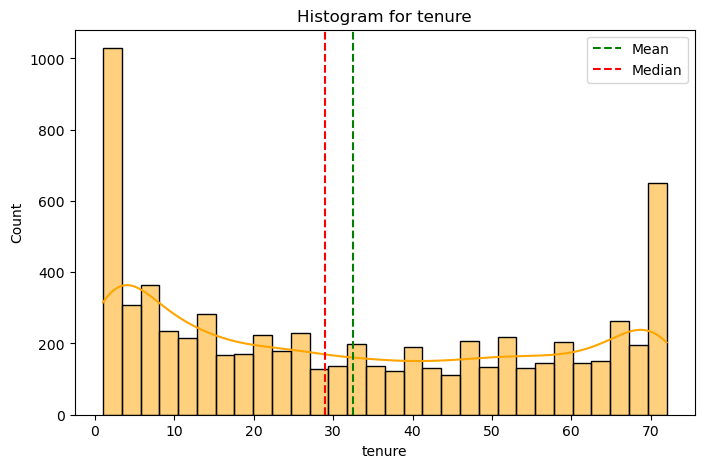

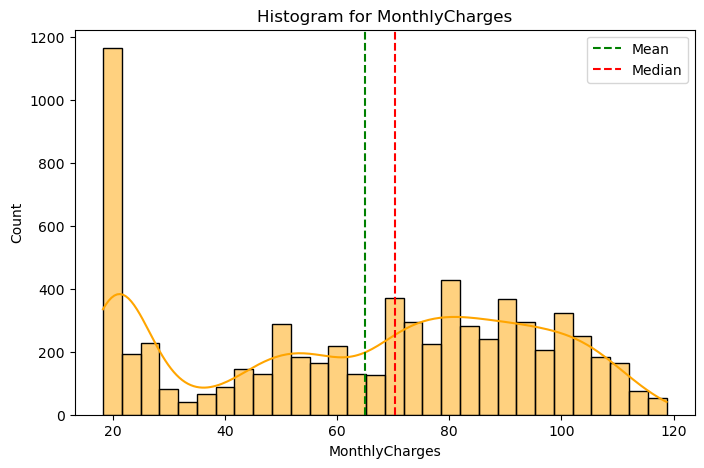

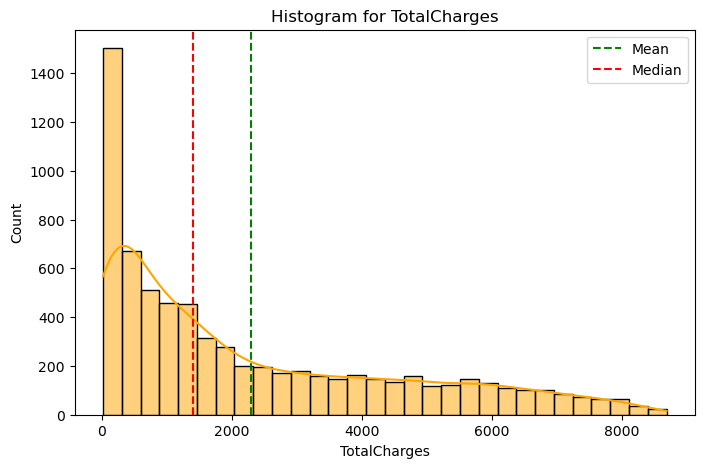

In [10]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop('SeniorCitizen')

for col in numeric_cols:
    histogram(df, col, 30, 'orange')

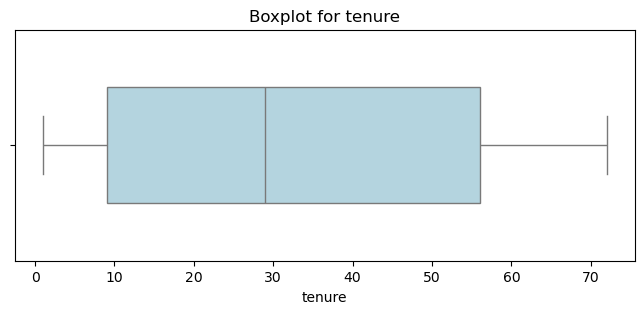

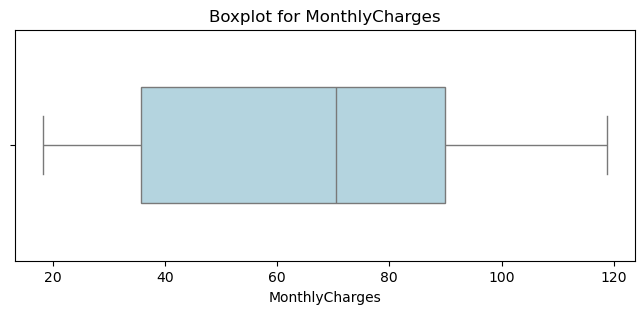

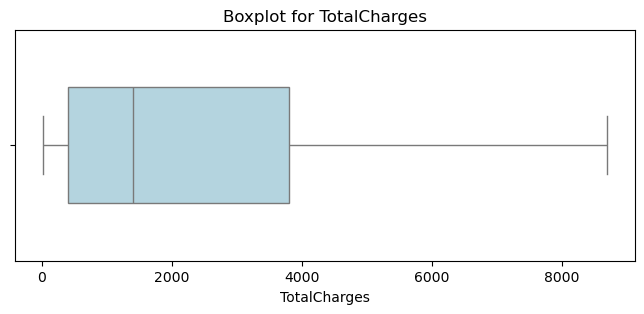

In [11]:
# box plots
for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(df, x=col, color='lightblue', width=0.5)
    plt.title(f"Boxplot for {col}")
    plt.show()

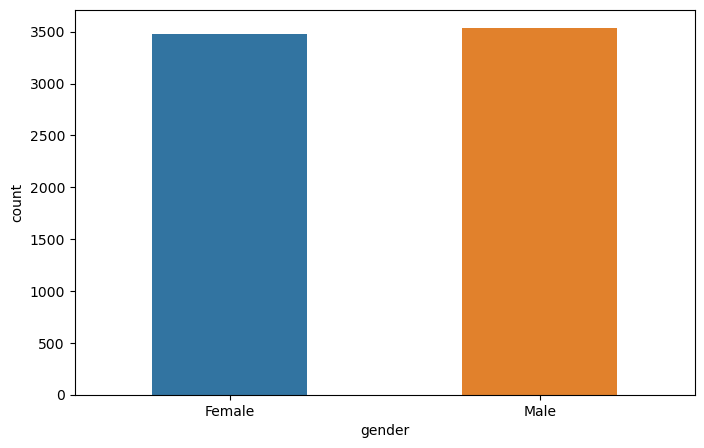

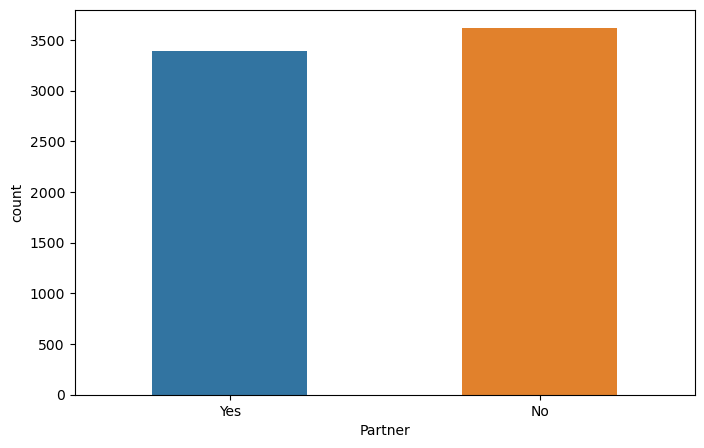

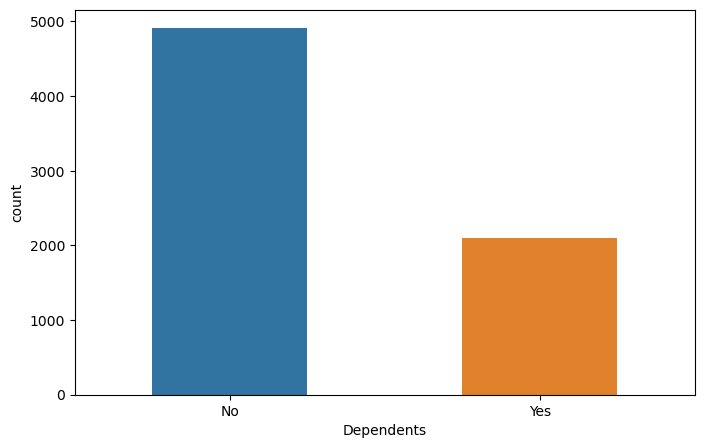

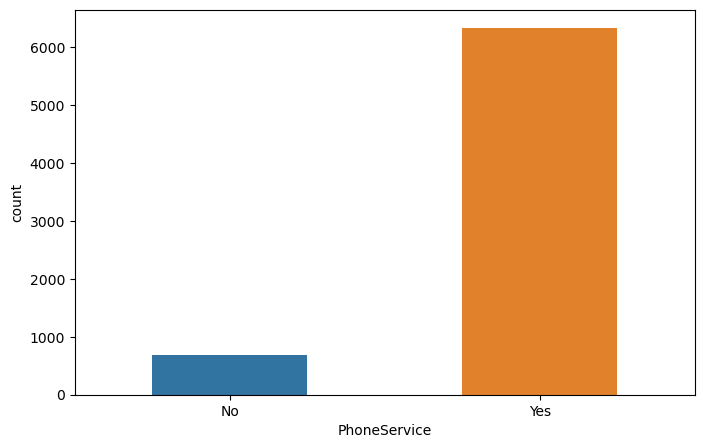

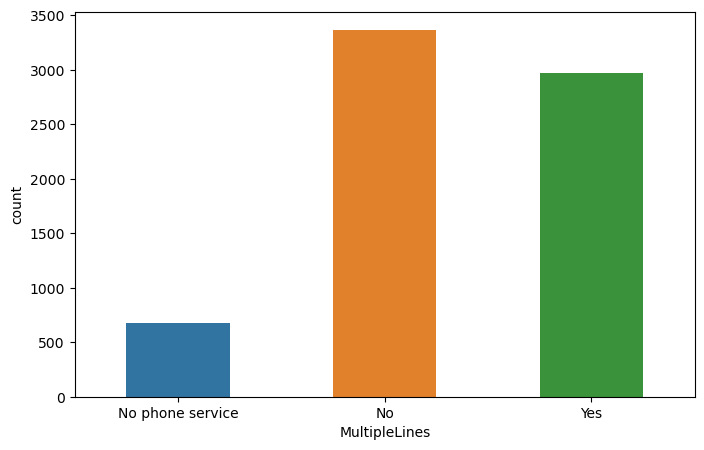

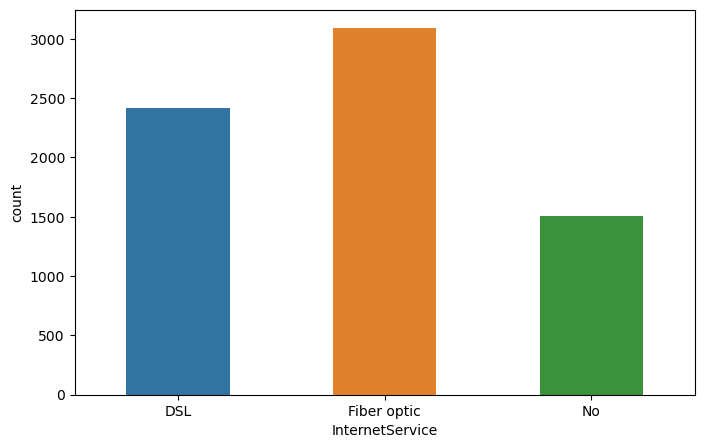

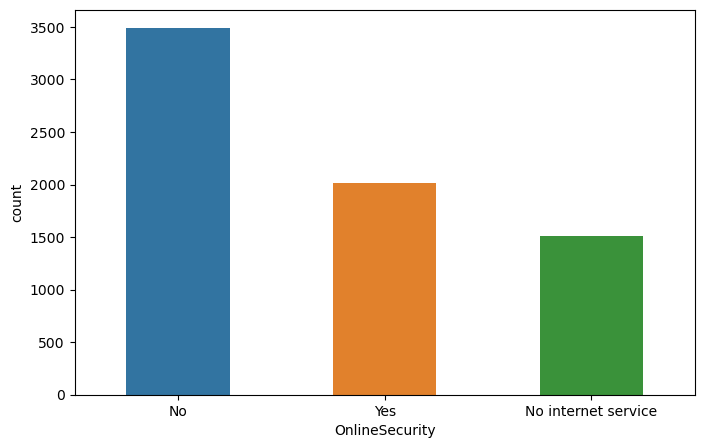

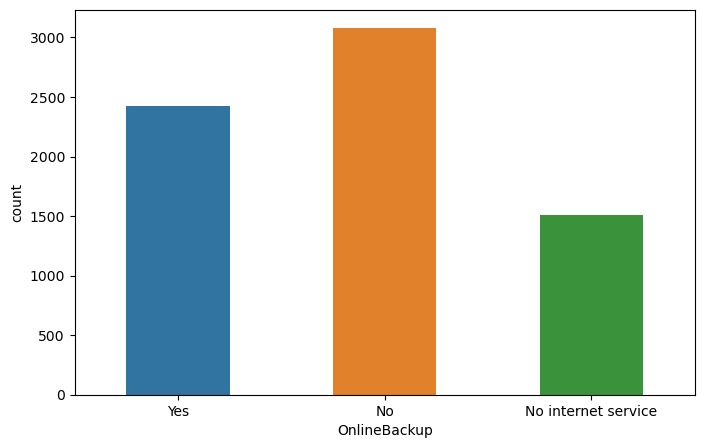

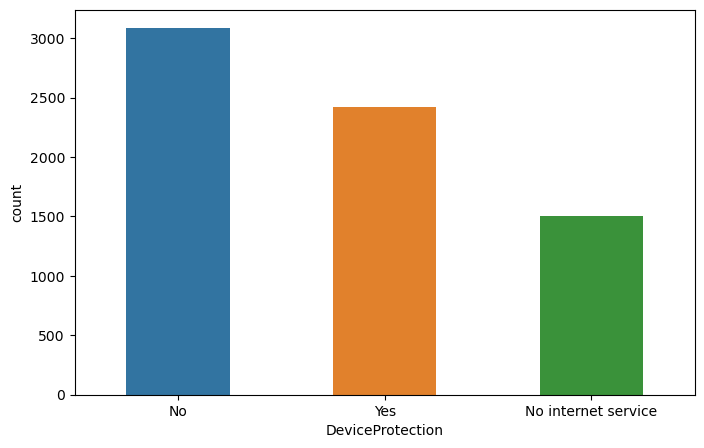

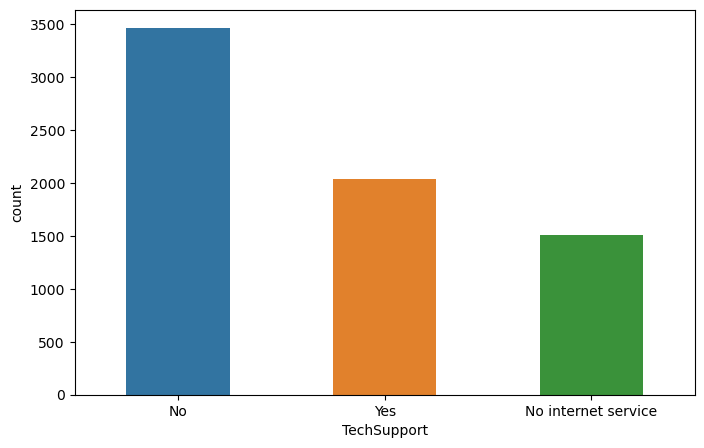

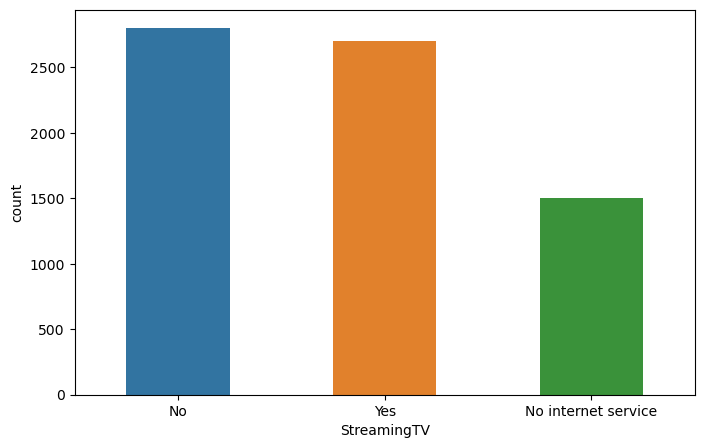

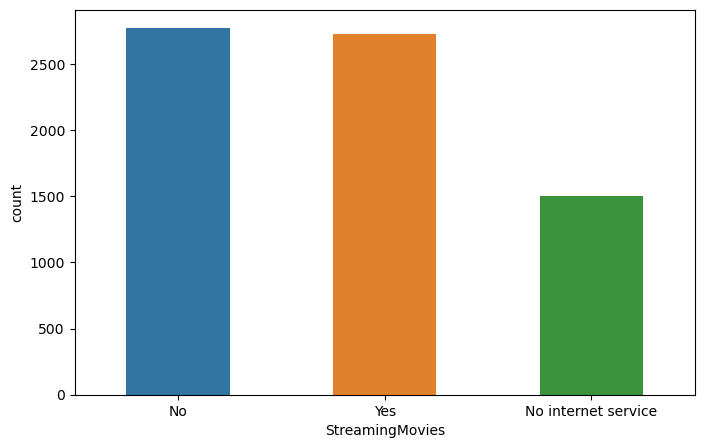

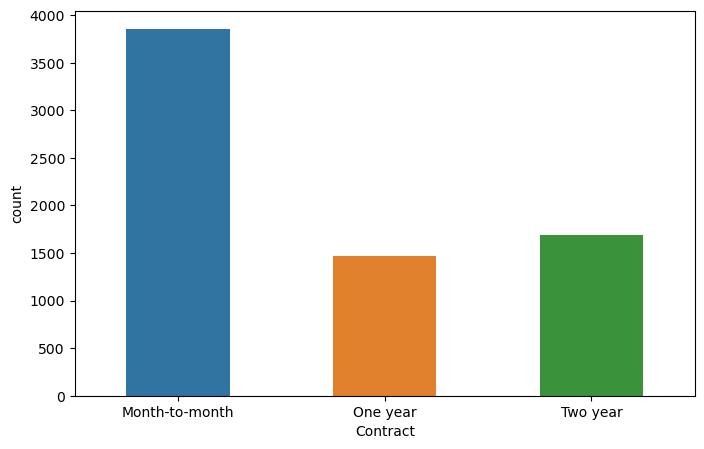

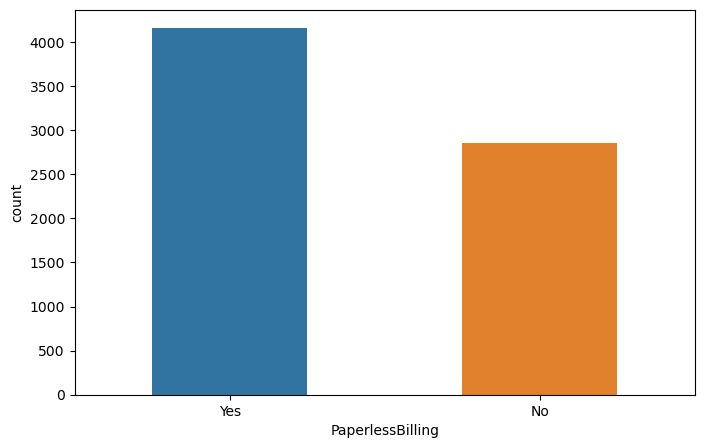

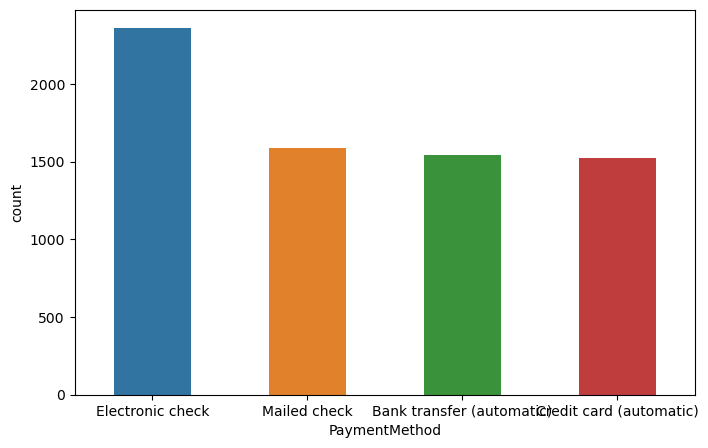

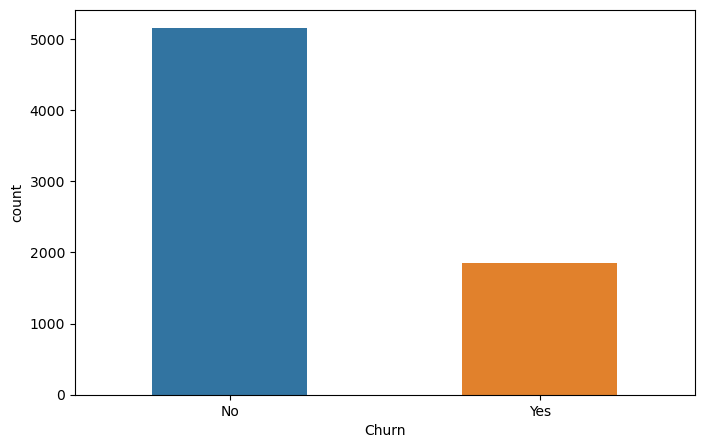

In [12]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col, hue=col, width=0.5)
    plt.show()

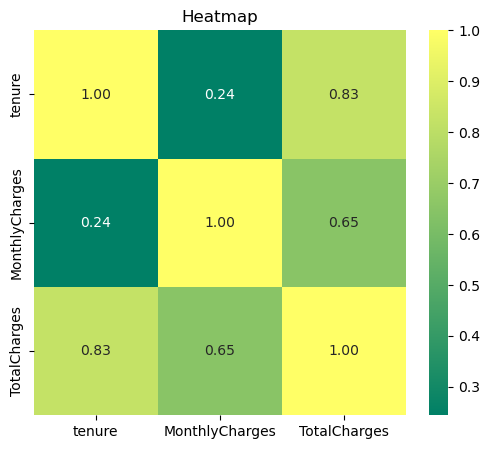

In [13]:
# correlation between numeric features
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='summer')
plt.title('Heatmap')
plt.show()

## Data Preprocessing

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# label encoding
preped_df = df.copy()
preped_df['Churn'].replace({'No': 0, 'Yes':1}, inplace=True)

C:\Users\Yogsh\AppData\Local\Temp\ipykernel_4396\549368783.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  preped_df['Churn'].replace({'No': 0, 'Yes':1}, inplace=True)


In [16]:
obj_cols = preped_df.select_dtypes(include='object').columns
obj_cols = obj_cols.drop(['PaymentMethod'])

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in obj_cols:
    preped_df[col] = label_encoder.fit_transform(preped_df[col])

In [18]:
preped_df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2359
Mailed check                 1588
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [19]:
from sklearn.preprocessing import OneHotEncoder
oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = oh_encoder.fit_transform(preped_df[['PaymentMethod']])

encoded_df = pd.DataFrame(
    encoded,
    columns=oh_encoder.get_feature_names_out(),
    index=preped_df.index
)
encoded_df.head()

,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0


In [20]:
final_df = pd.concat([preped_df, encoded_df], axis=1)
final_df.drop(columns=['PaymentMethod'], inplace=True)
final_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,0,0,2,...,0,0,1,29.85,29.85,0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,0,2,0,...,0,1,0,56.95,1889.50,0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,1,53.85,108.15,1,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,1,0,2,0,...,0,1,0,42.30,1840.75,0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,1,70.70,151.65,1,0.0,0.0,1.0,0.0


In [21]:
final_df['Churn'].value_counts()

Churn
0    5153
1    1857
Name: count, dtype: int64

In [31]:
X = final_df.drop(columns=['Churn'], axis=1)
y = final_df['Churn']

from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority')
X_resampled, y_resampled = smote.fit_resample(X,y)
X_resampled.shape, y_resampled.shape

((10306, 22), (10306,))

## Modeling

In [41]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X_resampled,y_resampled,test_size=0.2, stratify=y_resampled)

# setting up hyper-parameters for tuning 
grid = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'max_depth': [2,5,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf': [2,5,10],
    'max_features': [None, 'sqrt']
}

classifier = RandomForestClassifier(n_jobs=1)
rfc_search_model = RandomizedSearchCV(estimator=classifier, 
                                      param_distributions=grid,
                                      cv=5,
                                      n_iter=10,
                                      verbose=2
                                      )
rfc_search_model.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   2.2s
[CV] END max_depth=10, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   2.1s
[CV] END max_depth=10, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   2.1s
[CV] END max_depth=10, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   2.2s
[CV] END max_depth=10, max_features=None, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   2.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=1000; total time=   7.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=1000; total time=   9.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimat

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...fier(n_jobs=1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [2, 5, ...], 'max_features': [None, 'sqrt'], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [44]:
y_preds = rfc_search_model.predict(X_test)
accuracy_score(y_test, y_preds)

0.8501454898157129

In [47]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1031
           1       0.83      0.88      0.85      1031

    accuracy                           0.85      2062
   macro avg       0.85      0.85      0.85      2062
weighted avg       0.85      0.85      0.85      2062

